In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
dataframe = pd.read_csv("Zomato-data-.csv")
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [4]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate']=dataframe['rate'].apply(handleRate)
print(dataframe.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


C:\Users\sarve\AppData\Local\Temp\ipykernel_24720\91021357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe['listed_in(type)'], palette=colors)


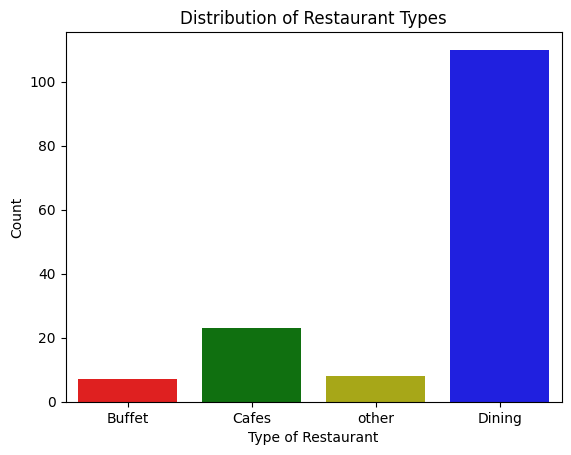

In [8]:
colors = ["r", "g", "y", "b"]

sns.countplot(x=dataframe['listed_in(type)'], palette=colors)
plt.xlabel("Type of Restaurant")
plt.ylabel("Count")
plt.title("Distribution of Restaurant Types")
plt.show()

Text(0, 0.5, 'Votes')

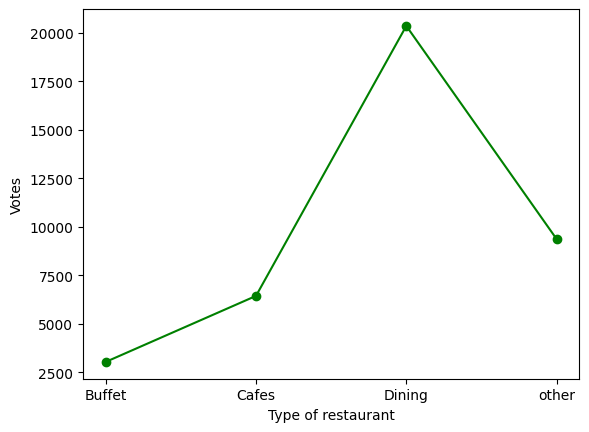

In [9]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

In [10]:
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] == max_votes, 'name']

print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


C:\Users\sarve\AppData\Local\Temp\ipykernel_24720\3518737076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=dataframe['online_order'], palette=colors)


<Axes: xlabel='online_order', ylabel='count'>

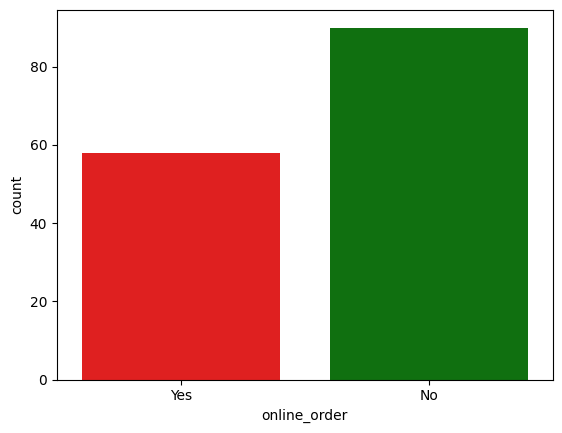

In [13]:
colors = ["r", "g"]
sns.countplot(x=dataframe['online_order'], palette=colors)


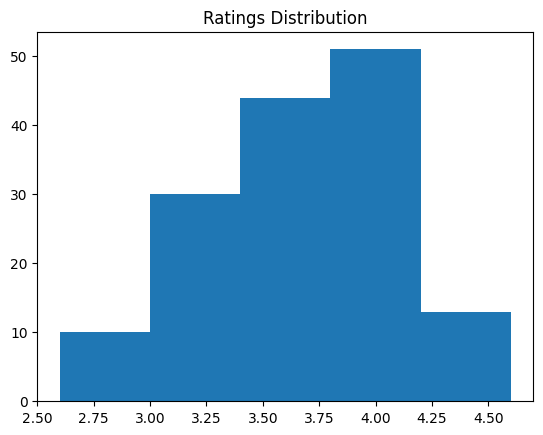

In [14]:
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

C:\Users\sarve\AppData\Local\Temp\ipykernel_24720\2597045760.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=couple_data, palette=colors)
C:\Users\sarve\AppData\Local\Temp\ipykernel_24720\2597045760.py:3: UserWarning: 
The palette list has fewer values (7) than needed (18) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x=couple_data, palette=colors)


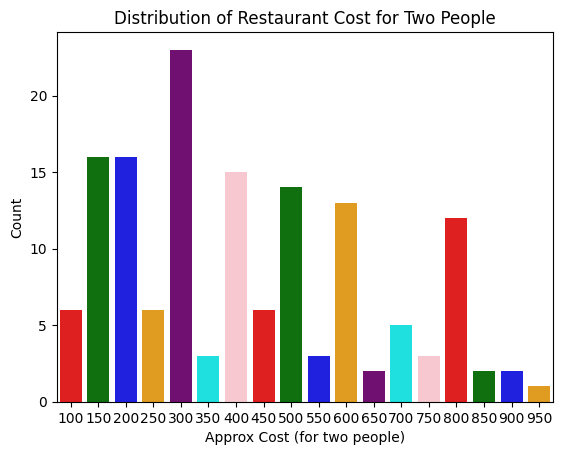

In [16]:
colors = ["red", "green", "blue", "orange", "purple", "cyan", "pink"]

sns.countplot(x=couple_data, palette=colors)
plt.xlabel("Approx Cost (for two people)")
plt.ylabel("Count")
plt.title("Distribution of Restaurant Cost for Two People")
plt.show()

C:\Users\sarve\AppData\Local\Temp\ipykernel_24720\4268417998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='online_order', y='rate', data=dataframe, palette={'Yes': 'green', 'No': 'red'})


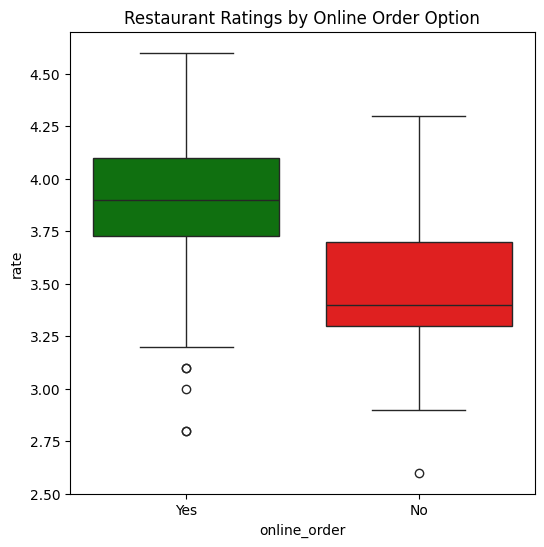

In [18]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order', y='rate', data=dataframe, palette={'Yes': 'green', 'No': 'red'})
plt.title("Restaurant Ratings by Online Order Option")
plt.show()


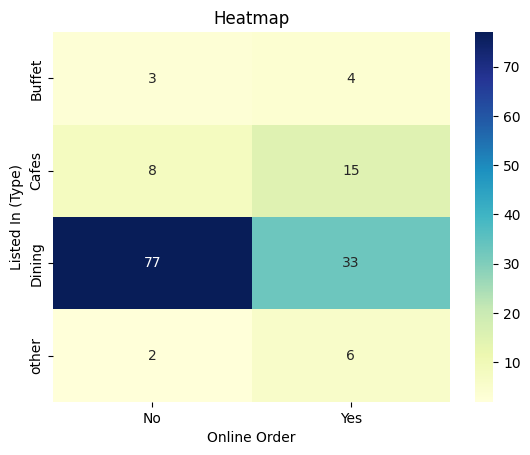

In [19]:
pivot_table = dataframe.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()